In [1]:
from pathlib import Path
import sys

_here = Path.cwd().resolve()
_candidates = (_here, *_here.parents)
REPO_ROOT = next((candidate for candidate in _candidates if (candidate / "m33_pipeline").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root from {Path.cwd()}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from m33_pipeline.notebook_setup import prepare_notebook

REPO_ROOT = prepare_notebook(REPO_ROOT)
print(f"Notebook working directory set to: {REPO_ROOT}")

Notebook working directory set to: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1


# M33 Notebook 1: Make the RGB mosaic

Read in the flux maps and combine them into an RGB mosaic of the galaxy, with zoom ins showing certain regions.

In [2]:
import os
import numpy as np

from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import AsinhStretch, PercentileInterval
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd
from reproject import reproject_interp

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=20)

plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [3]:
def save_color_mosaic(
    directory_maps,
    color_to_lines,
    labels=None,
    color_rgb=None,
    cmap=None,
    attempt="v1",
    output_basename="M33-ColorComposite",
    require_all_lines_per_tile=True,
    # ---- zoom options ----
    zoom_center_pix=None,
    zoom_center_sky=None,
    zoom_size=250,
    zoom_loc="upper right",
    zoom_inset_frac=0.35,
    zoom_box_color="white",
    zoom_box_lw=1.5,
    zoom_mark=True,
    zooms=None,
    # ---- NEW: per-channel display controls ----
    channel_percentile=None,        # dict: {color: pct} e.g. {"blue":99.9, "green":99.5, "red":99.0}
    channel_gamma=None,             # dict: {color: gamma} e.g. {"blue":0.6, "green":1.0, "red":0.8}
    channel_sky_percentile=5.0,     # float or dict: sky subtraction percentile (default 5)
):
    """
    Build a WCS-aligned mosaic where each "color" can be the sum of multiple emission-line maps.
    Produces an RGB composite and an annotated PDF preview with optional zoom insets.

    NEW controls:
      - channel_percentile: per-color upper percentile for stretching (PercentileInterval)
      - channel_gamma: per-color gamma correction after stretching (I -> I**gamma)
      - channel_sky_percentile: per-color sky percentile (or scalar) for background subtraction
    """

    # --- normalize inputs: ensure each dict value is a list ---
    color_to_lines_norm = {}
    for color, lines in color_to_lines.items():
        if isinstance(lines, (list, tuple, set)):
            color_to_lines_norm[color] = list(lines)
        else:
            color_to_lines_norm[color] = [lines]

    # --- default labels ---
    if labels is None:
        labels = {c: " + ".join(color_to_lines_norm[c]) for c in color_to_lines_norm}

    # --- default color palette ---
    default_palette = {
        "red": (1.0, 0.0, 0.0),
        "green": (0.0, 1.0, 0.0),
        "blue": (0.0, 0.0, 1.0),
        "cyan": (0.0, 1.0, 1.0),
        "magenta": (1.0, 0.0, 1.0),
        "yellow": (1.0, 1.0, 0.0),
        "orange": (1.0, 0.55, 0.0),
        "purple": (0.6, 0.2, 0.8),
        "white": (1.0, 1.0, 1.0),
    }

    if color_rgb is None:
        color_rgb = {}

    # Resolve each color -> rgb triple
    resolved_rgb = {}
    for c in color_to_lines_norm:
        if c in color_rgb:
            resolved_rgb[c] = tuple(color_rgb[c])
        elif c.lower() in default_palette:
            resolved_rgb[c] = default_palette[c.lower()]
        else:
            try:
                from matplotlib.colors import to_rgb
                resolved_rgb[c] = to_rgb(c)
            except Exception:
                resolved_rgb[c] = (1.0, 1.0, 1.0)

    # --- Collect per-color inputs for mosaicking ---
    inputs_by_color = {c: [] for c in color_to_lines_norm}

    folders = [f for f in os.listdir(directory_maps) if f != ".DS_Store"]
    folders.sort()

    for folder in folders:
        folder_path = os.path.join(directory_maps, folder)
        folder_end = folder_path[-2:]  # your convention

        needed_paths = []
        per_color_paths = {}
        for c, lines in color_to_lines_norm.items():
            line_paths = [os.path.join(folder_path, f"M33{folder_end}-{ln}.fits") for ln in lines]
            per_color_paths[c] = line_paths
            needed_paths.extend(line_paths)

        if require_all_lines_per_tile:
            if not all(os.path.exists(p) for p in needed_paths):
                print(f"Skipping {folder_end} (missing one or more required files)")
                continue

        ref_path = next((p for p in needed_paths if os.path.exists(p)), None)
        if ref_path is None:
            print(f"Skipping {folder_end} (no files found)")
            continue

        href = fits.open(ref_path)[0]
        wref = WCS(href.header)

        for c, line_paths in per_color_paths.items():
            datas = []
            for p in line_paths:
                if not os.path.exists(p):
                    if require_all_lines_per_tile:
                        datas = []
                        break
                    else:
                        continue

                h = fits.open(p)[0]
                d = np.where(np.isfinite(h.data), h.data / 1e-17, np.nan)
                datas.append(d)

            if len(datas) == 0:
                continue

            summed = np.nansum(np.stack(datas, axis=0), axis=0)
            # use WCS from the first file that contributed to this summed image
            w_this = None
            for p in line_paths:
                if os.path.exists(p):
                    w_this = WCS(fits.getheader(p))
                    break

            if w_this is None:
                continue

            inputs_by_color[c].append((summed, w_this))


    valid_colors = [c for c in inputs_by_color if len(inputs_by_color[c]) > 0]
    if not valid_colors:
        raise ValueError("No valid inputs found for any color.")

    wcs_out, shape_out = find_optimal_celestial_wcs(inputs_by_color[valid_colors[0]])

    mosaics = {}
    for c in valid_colors:
        plane, _ = reproject_and_coadd(
            inputs_by_color[c],
            wcs_out,
            shape_out=shape_out,
            reproject_function=reproject_interp,
        )
        mosaics[c] = plane

    # ---- NEW: setup per-channel defaults ----
    if channel_percentile is None:
        channel_percentile = {}
    if channel_gamma is None:
        channel_gamma = {}

    def get_sky_pct(color):
        if isinstance(channel_sky_percentile, dict):
            return float(channel_sky_percentile.get(color, 5.0))
        return float(channel_sky_percentile)

    def get_hi_pct(color):
        return float(channel_percentile.get(color, 99.5))

    def get_gamma(color):
        return float(channel_gamma.get(color, 1.0))

    # --- normalization now takes per-color parameters ---
    def normalize(x, hi_pct=99.5, sky_pct=5.0, gamma=1.0):
        x = np.nan_to_num(x, nan=0.0)

        pos = x[x > 0]
        if pos.size > 0:
            sky = np.percentile(pos, sky_pct)
        else:
            sky = 0.0

        x = x - sky
        x[x < 0] = 0.0

        # stretch to [0,1] based on per-channel high percentile
        stretch = AsinhStretch() + PercentileInterval(hi_pct)
        x = stretch(x)
        x = np.clip(x, 0, 1)

        # gamma correction
        if gamma != 1.0:
            x = np.power(x, gamma)

        return np.clip(x, 0, 1)

    # --- additive color mixing into RGB ---
    rgb = np.zeros((shape_out[0], shape_out[1], 3), dtype=float)
    for c in valid_colors:
        In = normalize(
            mosaics[c],
            hi_pct=get_hi_pct(c),
            sky_pct=get_sky_pct(c),
            gamma=get_gamma(c),
        )
        cr, cg, cb = resolved_rgb[c]
        rgb[..., 0] += In * cr
        rgb[..., 1] += In * cg
        rgb[..., 2] += In * cb

    rgb = np.clip(rgb, 0, 1)

    # optional: mask background where all planes are zero-ish
    total = np.zeros(shape_out, dtype=float)
    for c in valid_colors:
        total += np.nan_to_num(mosaics[c], nan=0.0)
    rgb[np.isnan(total) | (total == 0)] = 0.0

    # --- Plot and save PDF preview ---
    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(projection=wcs_out)
    ax.coords["ra"].set_ticklabel(size=8)
    ax.coords["dec"].set_ticklabel(size=8)
    ax.imshow(rgb, origin="lower")
    ax.set_xlabel("RA", fontsize=10)
    ax.set_ylabel("Dec", fontsize=10)

    # -------------------------
    # Zoom insets (optional)
    # -------------------------
    if zooms is None:
        zooms = []

    # Backward-compat: if user still passes the old single-zoom args, convert to one-item list
    if ((zoom_center_pix is not None) or (zoom_center_sky is not None)) and (len(zooms) == 0):
        zooms = [dict(
            center_pix=zoom_center_pix,
            center_sky=zoom_center_sky,
            size=zoom_size,
            inset_pos=None,
            loc=zoom_loc,
            frac=zoom_inset_frac,
            color=zoom_box_color,
            lw=zoom_box_lw,
            mark=zoom_mark,
        )]

    for zspec in zooms:
        size = zspec.get("size", zoom_size)
        box_color = zspec.get("color", zoom_box_color)
        lw = zspec.get("lw", zoom_box_lw)
        mark = zspec.get("mark", zoom_mark)

        center_pix = zspec.get("center_pix", None)
        center_sky = zspec.get("center_sky", None)

        if (center_pix is None) and (center_sky is None):
            continue

        if center_pix is not None:
            xc, yc = center_pix
        else:
            if isinstance(center_sky, SkyCoord):
                sc = center_sky
            else:
                ra_deg, dec_deg = center_sky
                sc = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame="icrs")
            xc, yc = wcs_out.world_to_pixel(sc)

        half = size / 2.0
        x0 = int(np.floor(xc - half))
        x1 = int(np.ceil(xc + half))
        y0 = int(np.floor(yc - half))
        y1 = int(np.ceil(yc + half))

        H, W = rgb.shape[0], rgb.shape[1]
        x0c, x1c = max(0, x0), min(W, x1)
        y0c, y1c = max(0, y0), min(H, y1)

        if (x1c - x0c) < 2 or (y1c - y0c) < 2:
            continue

        rect = plt.Rectangle(
            (x0c, y0c),
            x1c - x0c,
            y1c - y0c,
            fill=False,
            edgecolor=box_color,
            linewidth=lw,
        )
        ax.add_patch(rect)

        inset_pos = zspec.get("inset_pos", None)  # (x0,y0,w,h) in axes fraction
        if inset_pos is not None:
            axins = ax.inset_axes(inset_pos, transform=ax.transAxes)
        else:
            loc = zspec.get("loc", zoom_loc)
            frac = zspec.get("frac", zoom_inset_frac)
            axins = inset_axes(
                ax,
                width=f"{100*frac:.0f}%",
                height=f"{100*frac:.0f}%",
                loc=loc,
                borderpad=1.0,
            )

        axins.imshow(rgb, origin="lower")
        axins.set_xlim(x0c, x1c)
        axins.set_ylim(y0c, y1c)
        axins.set_xticks([])
        axins.set_yticks([])
        for spine in axins.spines.values():
            spine.set_edgecolor(box_color)
            spine.set_linewidth(lw)

        if mark:
            loc1 = zspec.get("mark_loc1", 2)
            loc2 = zspec.get("mark_loc2", 4)
            mark_inset(ax, axins, loc1=loc1, loc2=loc2, fc="none", ec=box_color, lw=lw)

    # legend
    legend_patches = [Patch(color=resolved_rgb[c], label=labels.get(c, c)) for c in valid_colors]
    leg = ax.legend(
        handles=legend_patches,
        loc="lower left",
        facecolor="black",
        framealpha=0.7,
        edgecolor="white",
        fontsize=8,
    )
    for t in leg.get_texts():
        t.set_color("white")

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    os.makedirs("PAPER_PLOTS", exist_ok=True)
    pdf_path = f"PAPER_PLOTS/{output_basename}_{attempt}.pdf"
    plt.savefig(pdf_path, bbox_inches="tight", dpi=600, facecolor="white")
    plt.close(fig)
    print(f"Saved composite PDF preview: {pdf_path}")


    return rgb, wcs_out


In [4]:
color_to_lines = {
    "blue":  "OIII5007flux",
    "green": "Haflux",
    "red":   ["NII6584flux", "SII6716flux", "SII6731flux"],
}

color_labels = {
    "blue": r"[O III] $\lambda$5007",
    "green": r"H$\alpha$ $\lambda$6563",
    "red": r"[N II]$\lambda$6584 + [S II]$\lambda\lambda$6716,6731",    
}

channel_percentile = {
    "blue":  99.5,   
    "green": 99.5,  
    "red":   99.5,   
}

channel_gamma = {
    "blue":  0.6,    
    "green": 0.6,
    "red":   0.6,
}

zooms = [
    dict(center_pix=(3000, 3500), size=700, inset_pos=(0.05, 0.1, 0.3, 0.3), color="white"),
    dict(center_pix=(3200, 5500), size=700, inset_pos=(0.75, 0.65, 0.3, 0.3), color="white"),
]
 
channel_sky_percentile = {
    "blue":  2.0,
    "green": 5.0,
    "red":   10.0,
}

rgb, wcs_out = save_color_mosaic(
    directory_maps="../M33-Maps-Calibrated/",
    color_to_lines=color_to_lines,
    labels=color_labels,
    attempt="v40",
    zooms=zooms,
    output_basename="M33_Mosaic",
    channel_percentile=channel_percentile,
    channel_sky_percentile=channel_sky_percentile,
    channel_gamma=channel_gamma,
) 


Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved composite PDF preview: PAPER_PLOTS/M33_Mosaic_v40.pdf


In [5]:
#this version trims the outer 50 pixels of each map
def save_color_mosaic(
    directory_maps,
    color_to_lines,
    labels=None,
    color_rgb=None,
    cmap=None,
    attempt="v1",
    output_basename="M33-ColorComposite",
    require_all_lines_per_tile=True,

    # ---- edge handling ----
    edge_taper=50,   # pixels over which tile edges are downweighted smoothly

    # ---- zoom options ----
    zoom_center_pix=None,
    zoom_center_sky=None,
    zoom_size=250,
    zoom_loc="upper right",
    zoom_inset_frac=0.35,
    zoom_box_color="white",
    zoom_box_lw=1.5,
    zoom_mark=True,
    zooms=None,

    # ---- per-channel display controls ----
    channel_percentile=None,
    channel_gamma=None,
    channel_sky_percentile=5.0,
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    from astropy.io import fits
    from astropy.wcs import WCS
    from astropy.coordinates import SkyCoord
    import astropy.units as u
    from astropy.visualization import AsinhStretch, PercentileInterval
    from reproject import reproject_interp
    from reproject.mosaicking import find_optimal_celestial_wcs

    from matplotlib.patches import Patch
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

    # -----------------------------
    # normalize inputs
    # -----------------------------
    color_to_lines_norm = {}
    for color, lines in color_to_lines.items():
        if isinstance(lines, (list, tuple, set)):
            color_to_lines_norm[color] = list(lines)
        else:
            color_to_lines_norm[color] = [lines]

    if labels is None:
        labels = {c: " + ".join(color_to_lines_norm[c]) for c in color_to_lines_norm}

    default_palette = {
        "red": (1.0, 0.0, 0.0),
        "green": (0.0, 1.0, 0.0),
        "blue": (0.0, 0.0, 1.0),
        "cyan": (0.0, 1.0, 1.0),
        "magenta": (1.0, 0.0, 1.0),
        "yellow": (1.0, 1.0, 0.0),
        "orange": (1.0, 0.55, 0.0),
        "purple": (0.6, 0.2, 0.8),
        "white": (1.0, 1.0, 1.0),
    }

    if color_rgb is None:
        color_rgb = {}

    resolved_rgb = {}
    for c in color_to_lines_norm:
        if c in color_rgb:
            resolved_rgb[c] = tuple(color_rgb[c])
        elif c.lower() in default_palette:
            resolved_rgb[c] = default_palette[c.lower()]
        else:
            try:
                from matplotlib.colors import to_rgb
                resolved_rgb[c] = to_rgb(c)
            except Exception:
                resolved_rgb[c] = (1.0, 1.0, 1.0)

    if channel_percentile is None:
        channel_percentile = {}
    if channel_gamma is None:
        channel_gamma = {}

    def get_sky_pct(color):
        if isinstance(channel_sky_percentile, dict):
            return float(channel_sky_percentile.get(color, 5.0))
        return float(channel_sky_percentile)

    def get_hi_pct(color):
        return float(channel_percentile.get(color, 99.5))

    def get_gamma(color):
        return float(channel_gamma.get(color, 1.0))

    def normalize(x, hi_pct=99.5, sky_pct=5.0, gamma=1.0):
        x = np.nan_to_num(x, nan=0.0)

        pos = x[x > 0]
        sky = np.percentile(pos, sky_pct) if pos.size > 0 else 0.0

        x = x - sky
        x[x < 0] = 0.0

        stretch = AsinhStretch() + PercentileInterval(hi_pct)
        x = stretch(x)
        x = np.clip(x, 0, 1)

        if gamma != 1.0:
            x = np.power(x, gamma)

        return np.clip(x, 0, 1)

    def make_edge_weight(shape, taper):
        """
        Smoothly downweight edges instead of hard-cutting them.
        Weight = 1 in the interior, ramps to 0 at the outer border.
        """
        ny, nx = shape
        if taper is None or taper <= 0:
            return np.ones((ny, nx), dtype=float)

        y = np.minimum(np.arange(ny), np.arange(ny)[::-1]).astype(float)
        x = np.minimum(np.arange(nx), np.arange(nx)[::-1]).astype(float)

        wy = np.clip(y / float(taper), 0.0, 1.0)
        wx = np.clip(x / float(taper), 0.0, 1.0)

        # outer product -> 2D separable taper
        w = np.outer(wy, wx)

        # gentle apodization
        w = np.sin(0.5 * np.pi * w) ** 2
        return w

    # -----------------------------
    # collect inputs
    # -----------------------------
    inputs_by_color = {c: [] for c in color_to_lines_norm}

    folders = [f for f in os.listdir(directory_maps) if f != ".DS_Store"]
    folders.sort()

    for folder in folders:
        folder_path = os.path.join(directory_maps, folder)
        folder_end = folder_path[-2:]

        needed_paths = []
        per_color_paths = {}
        for c, lines in color_to_lines_norm.items():
            line_paths = [os.path.join(folder_path, f"M33{folder_end}-{ln}.fits") for ln in lines]
            per_color_paths[c] = line_paths
            needed_paths.extend(line_paths)

        if require_all_lines_per_tile:
            if not all(os.path.exists(p) for p in needed_paths):
                print(f"Skipping {folder_end} (missing one or more required files)")
                continue

        ref_path = next((p for p in needed_paths if os.path.exists(p)), None)
        if ref_path is None:
            print(f"Skipping {folder_end} (no files found)")
            continue

        for c, line_paths in per_color_paths.items():
            datas = []
            w_this = None

            for p in line_paths:
                if not os.path.exists(p):
                    if require_all_lines_per_tile:
                        datas = []
                        break
                    else:
                        continue

                h = fits.open(p)[0]
                d = np.array(h.data, dtype=float)
                d = np.where(np.isfinite(d), d / 1e-17, np.nan)
                datas.append(d)

                if w_this is None:
                    w_this = WCS(h.header)

            if len(datas) == 0 or w_this is None:
                continue

            summed = np.nansum(np.stack(datas, axis=0), axis=0)

            # valid pixels from science image
            valid = np.isfinite(summed)

            # smooth edge weighting
            weight = make_edge_weight(summed.shape, edge_taper)
            weight[~valid] = 0.0

            # store summed image and weight separately
            inputs_by_color[c].append((summed, weight, w_this))

    valid_colors = [c for c in inputs_by_color if len(inputs_by_color[c]) > 0]
    if not valid_colors:
        raise ValueError("No valid inputs found for any color.")

    # output WCS from first valid color
    wcs_inputs = [(arr, w) for (arr, wt, w) in inputs_by_color[valid_colors[0]]]
    wcs_out, shape_out = find_optimal_celestial_wcs(wcs_inputs)

    # -----------------------------
    # weighted mosaics
    # -----------------------------
    mosaics = {}

    for c in valid_colors:
        num = np.zeros(shape_out, dtype=float)
        den = np.zeros(shape_out, dtype=float)

        for arr, wt, w_in in inputs_by_color[c]:
            arr0 = np.nan_to_num(arr, nan=0.0)
            weighted_arr = arr0 * wt

            reproj_num, _ = reproject_interp((weighted_arr, w_in), wcs_out, shape_out=shape_out)
            reproj_den, _ = reproject_interp((wt, w_in), wcs_out, shape_out=shape_out)

            reproj_num = np.nan_to_num(reproj_num, nan=0.0)
            reproj_den = np.nan_to_num(reproj_den, nan=0.0)

            num += reproj_num
            den += reproj_den

        plane = np.full(shape_out, np.nan, dtype=float)
        good = den > 1e-8
        plane[good] = num[good] / den[good]
        mosaics[c] = plane

    # -----------------------------
    # build RGB
    # -----------------------------
    rgb = np.zeros((shape_out[0], shape_out[1], 3), dtype=float)

    for c in valid_colors:
        In = normalize(
            mosaics[c],
            hi_pct=get_hi_pct(c),
            sky_pct=get_sky_pct(c),
            gamma=get_gamma(c),
        )
        cr, cg, cb = resolved_rgb[c]
        rgb[..., 0] += In * cr
        rgb[..., 1] += In * cg
        rgb[..., 2] += In * cb

    rgb = np.clip(rgb, 0, 1)

    total = np.zeros(shape_out, dtype=float)
    for c in valid_colors:
        total += np.nan_to_num(mosaics[c], nan=0.0)
    rgb[np.isnan(total) | (total == 0)] = 0.0

    # -----------------------------
    # plot
    # -----------------------------
    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(projection=wcs_out)
    ax.coords["ra"].set_ticklabel(size=8)
    ax.coords["dec"].set_ticklabel(size=8)
    ax.imshow(rgb, origin="lower")
    ax.set_xlabel("RA", fontsize=10)
    ax.set_ylabel("Dec", fontsize=10)

    # -------------------------
    # zoom insets
    # -------------------------
    if zooms is None:
        zooms = []

    if ((zoom_center_pix is not None) or (zoom_center_sky is not None)) and (len(zooms) == 0):
        zooms = [dict(
            center_pix=zoom_center_pix,
            center_sky=zoom_center_sky,
            size=zoom_size,
            inset_pos=None,
            loc=zoom_loc,
            frac=zoom_inset_frac,
            color=zoom_box_color,
            lw=zoom_box_lw,
            mark=zoom_mark,
        )]

    for zspec in zooms:
        size = zspec.get("size", zoom_size)
        box_color = zspec.get("color", zoom_box_color)
        lw = zspec.get("lw", zoom_box_lw)
        mark = zspec.get("mark", zoom_mark)

        center_pix = zspec.get("center_pix", None)
        center_sky = zspec.get("center_sky", None)

        if (center_pix is None) and (center_sky is None):
            continue

        if center_pix is not None:
            xc, yc = center_pix
        else:
            if isinstance(center_sky, SkyCoord):
                sc = center_sky
            else:
                ra_deg, dec_deg = center_sky
                sc = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame="icrs")
            xc, yc = wcs_out.world_to_pixel(sc)

        half = size / 2.0
        x0 = int(np.floor(xc - half))
        x1 = int(np.ceil(xc + half))
        y0 = int(np.floor(yc - half))
        y1 = int(np.ceil(yc + half))

        H, W = rgb.shape[0], rgb.shape[1]
        x0c, x1c = max(0, x0), min(W, x1)
        y0c, y1c = max(0, y0), min(H, y1)

        if (x1c - x0c) < 2 or (y1c - y0c) < 2:
            continue

        rect = plt.Rectangle(
            (x0c, y0c),
            x1c - x0c,
            y1c - y0c,
            fill=False,
            edgecolor=box_color,
            linewidth=lw,
        )
        ax.add_patch(rect)

        inset_pos = zspec.get("inset_pos", None)
        if inset_pos is not None:
            axins = ax.inset_axes(inset_pos, transform=ax.transAxes)
        else:
            loc = zspec.get("loc", zoom_loc)
            frac = zspec.get("frac", zoom_inset_frac)
            axins = inset_axes(
                ax,
                width=f"{100*frac:.0f}%",
                height=f"{100*frac:.0f}%",
                loc=loc,
                borderpad=1.0,
            )

        axins.imshow(rgb, origin="lower")
        axins.set_xlim(x0c, x1c)
        axins.set_ylim(y0c, y1c)
        axins.set_xticks([])
        axins.set_yticks([])
        for spine in axins.spines.values():
            spine.set_edgecolor(box_color)
            spine.set_linewidth(lw)

        if mark:
            loc1 = zspec.get("mark_loc1", 2)
            loc2 = zspec.get("mark_loc2", 4)
            mark_inset(ax, axins, loc1=loc1, loc2=loc2, fc="none", ec=box_color, lw=lw)

    # -------------------------
    # legend (cleaner)
    # -------------------------
    legend_patches = [Patch(color=resolved_rgb[c], label=labels.get(c, c)) for c in valid_colors]
    leg = ax.legend(
        handles=legend_patches,
        loc="lower left",
        fontsize=8,
        frameon=True,
        facecolor="black",
        edgecolor="white",
        framealpha=0.6,
        borderpad=0.6,
        labelspacing=0.5,
        handlelength=1.8,
        handleheight=0.8,
    )
    for t in leg.get_texts():
        t.set_color("white")

    fig.patch.set_facecolor("white")
    ax.set_facecolor("black")

    os.makedirs("PAPER_PLOTS", exist_ok=True)
    pdf_path = f"PAPER_PLOTS/{output_basename}_{attempt}.pdf"
    plt.savefig(pdf_path, bbox_inches="tight", dpi=600, facecolor="white")
    plt.close(fig)
    print(f"Saved composite PDF preview: {pdf_path}")

    return rgb, wcs_out

In [6]:
color_to_lines = {
    "blue":  "OIII5007flux",
    "green": "Haflux",
    "red":   ["NII6584flux", "SII6716flux", "SII6731flux"],
}

color_labels = {
    "blue":  r"[O III] $\lambda$5007",
    "green": r"H$\alpha$ $\lambda$6563",
    "red":   r"[N II]$\lambda$6584 + [S II]$\lambda\lambda$6716,6731",
}

channel_percentile = {
    "blue":  99.5,
    "green": 99.5,
    "red":   99.5,
}

channel_gamma = {
    "blue":  0.6,
    "green": 0.6,
    "red":   0.6,
}

channel_sky_percentile = {
    "blue":  2.0,
    "green": 5.0,
    "red":   10.0,
}

zooms = [
    dict(center_pix=(3000, 3500), size=700, inset_pos=(0.05, 0.1, 0.3, 0.3), color="white"),
    dict(center_pix=(3200, 5500), size=700, inset_pos=(0.75, 0.65, 0.3, 0.3), color="white"),
]

rgb, wcs_out = save_color_mosaic(
    directory_maps="../M33-Maps-Calibrated/",
    color_to_lines=color_to_lines,
    labels=color_labels,
    attempt="v42_tapered",
    output_basename="M33_Mosaic",
    zooms=zooms,
    channel_percentile=channel_percentile,
    channel_sky_percentile=channel_sky_percentile,
    channel_gamma=channel_gamma,
    edge_taper=50,
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved composite PDF preview: PAPER_PLOTS/M33_Mosaic_v42_tapered.pdf


In [7]:
def save_color_mosaic(
    directory_maps,
    color_to_lines,
    labels=None,
    color_rgb=None,
    cmap=None,
    attempt="v1",
    output_basename="M33-ColorComposite",
    require_all_lines_per_tile=True,

    # ---- edge handling ----
    edge_trim=20,    # hard trim first
    edge_taper=50,   # then smooth taper

    # ---- special field handling ----
    special_ha_match_oiii_fields=("F9",),   # fields where Halpha is masked to OIII footprint

    # ---- zoom options ----
    zoom_center_pix=None,
    zoom_center_sky=None,
    zoom_size=250,
    zoom_loc="upper right",
    zoom_inset_frac=0.35,
    zoom_box_color="white",
    zoom_box_lw=1.5,
    zoom_mark=True,
    zooms=None,

    # ---- per-channel display controls ----
    channel_percentile=None,
    channel_gamma=None,
    channel_sky_percentile=5.0,
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    from astropy.io import fits
    from astropy.wcs import WCS
    from astropy.coordinates import SkyCoord
    import astropy.units as u
    from astropy.visualization import AsinhStretch, PercentileInterval
    from reproject import reproject_interp
    from reproject.mosaicking import find_optimal_celestial_wcs

    from matplotlib.patches import Patch
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

    # -----------------------------
    # normalize inputs
    # -----------------------------
    color_to_lines_norm = {}
    for color, lines in color_to_lines.items():
        if isinstance(lines, (list, tuple, set)):
            color_to_lines_norm[color] = list(lines)
        else:
            color_to_lines_norm[color] = [lines]

    if labels is None:
        labels = {c: " + ".join(color_to_lines_norm[c]) for c in color_to_lines_norm}

    default_palette = {
        "red": (1.0, 0.0, 0.0),
        "green": (0.0, 1.0, 0.0),
        "blue": (0.0, 0.0, 1.0),
        "cyan": (0.0, 1.0, 1.0),
        "magenta": (1.0, 0.0, 1.0),
        "yellow": (1.0, 1.0, 0.0),
        "orange": (1.0, 0.55, 0.0),
        "purple": (0.6, 0.2, 0.8),
        "white": (1.0, 1.0, 1.0),
    }

    if color_rgb is None:
        color_rgb = {}

    resolved_rgb = {}
    for c in color_to_lines_norm:
        if c in color_rgb:
            resolved_rgb[c] = tuple(color_rgb[c])
        elif c.lower() in default_palette:
            resolved_rgb[c] = default_palette[c.lower()]
        else:
            try:
                from matplotlib.colors import to_rgb
                resolved_rgb[c] = to_rgb(c)
            except Exception:
                resolved_rgb[c] = (1.0, 1.0, 1.0)

    if channel_percentile is None:
        channel_percentile = {}
    if channel_gamma is None:
        channel_gamma = {}

    def get_sky_pct(color):
        if isinstance(channel_sky_percentile, dict):
            return float(channel_sky_percentile.get(color, 5.0))
        return float(channel_sky_percentile)

    def get_hi_pct(color):
        return float(channel_percentile.get(color, 99.5))

    def get_gamma(color):
        return float(channel_gamma.get(color, 1.0))

    def normalize(x, hi_pct=99.5, sky_pct=5.0, gamma=1.0):
        x = np.nan_to_num(x, nan=0.0)

        pos = x[x > 0]
        sky = np.percentile(pos, sky_pct) if pos.size > 0 else 0.0

        x = x - sky
        x[x < 0] = 0.0

        stretch = AsinhStretch() + PercentileInterval(hi_pct)
        x = stretch(x)
        x = np.clip(x, 0, 1)

        if gamma != 1.0:
            x = np.power(x, gamma)

        return np.clip(x, 0, 1)

    def make_edge_weight(shape, taper):
        ny, nx = shape
        if taper is None or taper <= 0:
            return np.ones((ny, nx), dtype=float)

        y = np.minimum(np.arange(ny), np.arange(ny)[::-1]).astype(float)
        x = np.minimum(np.arange(nx), np.arange(nx)[::-1]).astype(float)

        wy = np.clip(y / float(taper), 0.0, 1.0)
        wx = np.clip(x / float(taper), 0.0, 1.0)

        w = np.outer(wy, wx)
        w = np.sin(0.5 * np.pi * w) ** 2
        return w

    def trim_edges_inplace(data, trim):
        if trim is None or trim <= 0:
            return
        data[:trim, :] = np.nan
        data[-trim:, :] = np.nan
        data[:, :trim] = np.nan
        data[:, -trim:] = np.nan

    def field_name_from_folder(folder):
        return os.path.basename(folder).upper()

    def is_ha_line(line_name):
        s = line_name.lower()
        return ("ha" in s) or ("halpha" in s)

    def is_oiii_line(line_name):
        s = line_name.lower()
        return ("oiii" in s) or ("oiii5007" in s)

    # -----------------------------
    # collect inputs
    # -----------------------------
    inputs_by_color = {c: [] for c in color_to_lines_norm}

    folders = [f for f in os.listdir(directory_maps) if f != ".DS_Store"]
    folders.sort()

    for folder in folders:
        folder_path = os.path.join(directory_maps, folder)
        folder_end = folder_path[-2:]
        field_name = field_name_from_folder(folder)

        needed_paths = []
        per_color_paths = {}
        for c, lines in color_to_lines_norm.items():
            line_paths = [os.path.join(folder_path, f"M33{folder_end}-{ln}.fits") for ln in lines]
            per_color_paths[c] = line_paths
            needed_paths.extend(line_paths)

        if require_all_lines_per_tile:
            if not all(os.path.exists(p) for p in needed_paths):
                print(f"Skipping {folder_end} (missing one or more required files)")
                continue

        ref_path = next((p for p in needed_paths if os.path.exists(p)), None)
        if ref_path is None:
            print(f"Skipping {folder_end} (no files found)")
            continue

        # For special fields like F9, pre-load OIII valid mask so Halpha can be clipped to it
        oiii_valid_mask_for_field = None
        if field_name in {f.upper() for f in special_ha_match_oiii_fields}:
            print(f'correcting {field_name}')
            oiii_paths = []
            for c, lines in color_to_lines_norm.items():
                for ln in lines:
                    if is_oiii_line(ln):
                        oiii_paths.append(os.path.join(folder_path, f"M33{folder_end}-{ln}.fits"))

            for op in oiii_paths:
                if os.path.exists(op):
                    ohdu = fits.open(op)[0]
                    odata = np.array(ohdu.data, dtype=float)
                    oiii_valid_mask_for_field = np.isfinite(odata)
                    # trim OIII mask the same way
                    if edge_trim > 0:
                        oiii_valid_mask_for_field[:edge_trim, :] = False
                        oiii_valid_mask_for_field[-edge_trim:, :] = False
                        oiii_valid_mask_for_field[:, :edge_trim] = False
                        oiii_valid_mask_for_field[:, -edge_trim:] = False
                    break

        for c, line_paths in per_color_paths.items():
            datas = []
            w_this = None

            for p in line_paths:
                if not os.path.exists(p):
                    if require_all_lines_per_tile:
                        datas = []
                        break
                    else:
                        continue

                h = fits.open(p)[0]
                d = np.array(h.data, dtype=float)
                d = np.where(np.isfinite(d), d / 1e-17, np.nan)

                # 1) hard trim every map edge
                trim_edges_inplace(d, edge_trim)

                # 2) special case: for F9, force Halpha to only exist where OIII exists
                filename = os.path.basename(p)
                if (
                    field_name in {f.upper() for f in special_ha_match_oiii_fields}
                    and is_ha_line(filename)
                    and (oiii_valid_mask_for_field is not None)
                ):
                    d[~oiii_valid_mask_for_field] = np.nan

                datas.append(d)

                if w_this is None:
                    w_this = WCS(h.header)

            if len(datas) == 0 or w_this is None:
                continue

            summed = np.nansum(np.stack(datas, axis=0), axis=0)

            valid = np.isfinite(summed)
            weight = make_edge_weight(summed.shape, edge_taper)
            weight[~valid] = 0.0

            inputs_by_color[c].append((summed, weight, w_this))

    valid_colors = [c for c in inputs_by_color if len(inputs_by_color[c]) > 0]
    if not valid_colors:
        raise ValueError("No valid inputs found for any color.")

    wcs_inputs = [(arr, w) for (arr, wt, w) in inputs_by_color[valid_colors[0]]]
    wcs_out, shape_out = find_optimal_celestial_wcs(wcs_inputs)

    # -----------------------------
    # weighted mosaics
    # -----------------------------
    mosaics = {}

    for c in valid_colors:
        num = np.zeros(shape_out, dtype=float)
        den = np.zeros(shape_out, dtype=float)

        for arr, wt, w_in in inputs_by_color[c]:
            arr0 = np.nan_to_num(arr, nan=0.0)
            weighted_arr = arr0 * wt

            reproj_num, _ = reproject_interp((weighted_arr, w_in), wcs_out, shape_out=shape_out)
            reproj_den, _ = reproject_interp((wt, w_in), wcs_out, shape_out=shape_out)

            reproj_num = np.nan_to_num(reproj_num, nan=0.0)
            reproj_den = np.nan_to_num(reproj_den, nan=0.0)

            num += reproj_num
            den += reproj_den

        plane = np.full(shape_out, np.nan, dtype=float)
        good = den > 1e-8
        plane[good] = num[good] / den[good]
        mosaics[c] = plane

    # -----------------------------
    # build RGB
    # -----------------------------
    rgb = np.zeros((shape_out[0], shape_out[1], 3), dtype=float)

    for c in valid_colors:
        In = normalize(
            mosaics[c],
            hi_pct=get_hi_pct(c),
            sky_pct=get_sky_pct(c),
            gamma=get_gamma(c),
        )
        cr, cg, cb = resolved_rgb[c]
        rgb[..., 0] += In * cr
        rgb[..., 1] += In * cg
        rgb[..., 2] += In * cb

    rgb = np.clip(rgb, 0, 1)

    total = np.zeros(shape_out, dtype=float)
    for c in valid_colors:
        total += np.nan_to_num(mosaics[c], nan=0.0)
    rgb[np.isnan(total) | (total == 0)] = 0.0

    # -----------------------------
    # plot
    # -----------------------------
    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(projection=wcs_out)
    ax.coords["ra"].set_ticklabel(size=8)
    ax.coords["dec"].set_ticklabel(size=8)
    ax.imshow(rgb, origin="lower")
    ax.set_xlabel("RA", fontsize=10)
    ax.set_ylabel("Dec", fontsize=10)

    # zooms
    if zooms is None:
        zooms = []

    if ((zoom_center_pix is not None) or (zoom_center_sky is not None)) and (len(zooms) == 0):
        zooms = [dict(
            center_pix=zoom_center_pix,
            center_sky=zoom_center_sky,
            size=zoom_size,
            inset_pos=None,
            loc=zoom_loc,
            frac=zoom_inset_frac,
            color=zoom_box_color,
            lw=zoom_box_lw,
            mark=zoom_mark,
        )]

    for zspec in zooms:
        size = zspec.get("size", zoom_size)
        box_color = zspec.get("color", zoom_box_color)
        lw = zspec.get("lw", zoom_box_lw)
        mark = zspec.get("mark", zoom_mark)

        center_pix = zspec.get("center_pix", None)
        center_sky = zspec.get("center_sky", None)

        if (center_pix is None) and (center_sky is None):
            continue

        if center_pix is not None:
            xc, yc = center_pix
        else:
            if isinstance(center_sky, SkyCoord):
                sc = center_sky
            else:
                ra_deg, dec_deg = center_sky
                sc = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame="icrs")
            xc, yc = wcs_out.world_to_pixel(sc)

        half = size / 2.0
        x0 = int(np.floor(xc - half))
        x1 = int(np.ceil(xc + half))
        y0 = int(np.floor(yc - half))
        y1 = int(np.ceil(yc + half))

        H, W = rgb.shape[0], rgb.shape[1]
        x0c, x1c = max(0, x0), min(W, x1)
        y0c, y1c = max(0, y0), min(H, y1)

        if (x1c - x0c) < 2 or (y1c - y0c) < 2:
            continue

        rect = plt.Rectangle(
            (x0c, y0c),
            x1c - x0c,
            y1c - y0c,
            fill=False,
            edgecolor=box_color,
            linewidth=lw,
        )
        ax.add_patch(rect)

        inset_pos = zspec.get("inset_pos", None)
        if inset_pos is not None:
            axins = ax.inset_axes(inset_pos, transform=ax.transAxes)
        else:
            loc = zspec.get("loc", zoom_loc)
            frac = zspec.get("frac", zoom_inset_frac)
            axins = inset_axes(
                ax,
                width=f"{100*frac:.0f}%",
                height=f"{100*frac:.0f}%",
                loc=loc,
                borderpad=1.0,
            )

        axins.imshow(rgb, origin="lower")
        axins.set_xlim(x0c, x1c)
        axins.set_ylim(y0c, y1c)
        axins.set_xticks([])
        axins.set_yticks([])
        for spine in axins.spines.values():
            spine.set_edgecolor(box_color)
            spine.set_linewidth(lw)

        if mark:
            loc1 = zspec.get("mark_loc1", 2)
            loc2 = zspec.get("mark_loc2", 4)
            mark_inset(ax, axins, loc1=loc1, loc2=loc2, fc="none", ec=box_color, lw=lw)

    legend_patches = [Patch(color=resolved_rgb[c], label=labels.get(c, c)) for c in valid_colors]
    leg = ax.legend(
        handles=legend_patches,
        loc="lower left",
        fontsize=8,
        frameon=True,
        facecolor="black",
        edgecolor="white",
        framealpha=0.6,
        borderpad=0.6,
        labelspacing=0.5,
        handlelength=1.8,
        handleheight=0.8,
    )
    for t in leg.get_texts():
        t.set_color("white")

    fig.patch.set_facecolor("white")
    ax.set_facecolor("black")

    os.makedirs("PAPER_PLOTS", exist_ok=True)
    pdf_path = f"PAPER_PLOTS/{output_basename}_{attempt}.pdf"
    plt.savefig(pdf_path, bbox_inches="tight", dpi=600, facecolor="white")
    plt.close(fig)
    print(f"Saved composite PDF preview: {pdf_path}")

    return rgb, wcs_out

In [8]:
color_to_lines = {
    "blue":  "OIII5007flux",
    "green": "Haflux",
    "red":   ["NII6584flux", "SII6716flux", "SII6731flux"],
}

color_labels = {
    "blue":  r"[O III] $\lambda$5007",
    "green": r"H$\alpha$ $\lambda$6563",
    "red":   r"[N II]$\lambda$6584 + [S II]$\lambda\lambda$6716,6731",
}

channel_percentile = {
    "blue":  99.5,
    "green": 99.5,
    "red":   99.5,
}

channel_gamma = {
    "blue":  0.6,
    "green": 0.6,
    "red":   0.6,
}

channel_sky_percentile = {
    "blue":  2.0,
    "green": 5.0,
    "red":   10.0,
}

zooms = [
    dict(center_pix=(3000, 3500), size=700, inset_pos=(0.05, 0.1, 0.3, 0.3), color="white"),
    dict(center_pix=(3200, 5500), size=700, inset_pos=(0.75, 0.65, 0.3, 0.3), color="white"),
]

rgb, wcs_out = save_color_mosaic(
    directory_maps="../M33-Maps-Calibrated/",
    color_to_lines=color_to_lines,
    labels=color_labels,
    attempt="v44_trim40",
    output_basename="M33_Mosaic",
    zooms=zooms,
    channel_percentile=channel_percentile,
    channel_sky_percentile=channel_sky_percentile,
    channel_gamma=channel_gamma,

    edge_trim=30,
    edge_taper=70,
    special_ha_match_oiii_fields=("M33-F9",),
)

correcting M33-F9
Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved composite PDF preview: PAPER_PLOTS/M33_Mosaic_v44_trim40.pdf


In [9]:
def save_color_mosaic(
    directory_maps,
    color_to_lines,
    labels=None,
    color_rgb=None,
    cmap=None,
    attempt="v1",
    output_basename="M33-ColorComposite",
    require_all_lines_per_tile=True,

    # ---- edge handling ----
    edge_trim=20,    # hard trim after special masking
    edge_taper=50,   # then smooth taper

    # ---- special field handling ----
    special_match_oiii_fields=("F9",),   # fields where Ha/NII/SII are masked to OIII footprint

    # ---- zoom options ----
    zoom_center_pix=None,
    zoom_center_sky=None,
    zoom_size=250,
    zoom_loc="upper right",
    zoom_inset_frac=0.35,
    zoom_box_color="white",
    zoom_box_lw=1.5,
    zoom_mark=True,
    zooms=None,

    # ---- per-channel display controls ----
    channel_percentile=None,
    channel_gamma=None,
    channel_sky_percentile=5.0,
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    from astropy.io import fits
    from astropy.wcs import WCS
    from astropy.coordinates import SkyCoord
    import astropy.units as u
    from astropy.visualization import AsinhStretch, PercentileInterval
    from reproject import reproject_interp
    from reproject.mosaicking import find_optimal_celestial_wcs

    from matplotlib.patches import Patch
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

    # -----------------------------
    # normalize inputs
    # -----------------------------
    color_to_lines_norm = {}
    for color, lines in color_to_lines.items():
        if isinstance(lines, (list, tuple, set)):
            color_to_lines_norm[color] = list(lines)
        else:
            color_to_lines_norm[color] = [lines]

    if labels is None:
        labels = {c: " + ".join(color_to_lines_norm[c]) for c in color_to_lines_norm}

    default_palette = {
        "red": (1.0, 0.0, 0.0),
        "green": (0.0, 1.0, 0.0),
        "blue": (0.0, 0.0, 1.0),
        "cyan": (0.0, 1.0, 1.0),
        "magenta": (1.0, 0.0, 1.0),
        "yellow": (1.0, 1.0, 0.0),
        "orange": (1.0, 0.55, 0.0),
        "purple": (0.6, 0.2, 0.8),
        "white": (1.0, 1.0, 1.0),
    }

    if color_rgb is None:
        color_rgb = {}

    resolved_rgb = {}
    for c in color_to_lines_norm:
        if c in color_rgb:
            resolved_rgb[c] = tuple(color_rgb[c])
        elif c.lower() in default_palette:
            resolved_rgb[c] = default_palette[c.lower()]
        else:
            try:
                from matplotlib.colors import to_rgb
                resolved_rgb[c] = to_rgb(c)
            except Exception:
                resolved_rgb[c] = (1.0, 1.0, 1.0)

    if channel_percentile is None:
        channel_percentile = {}
    if channel_gamma is None:
        channel_gamma = {}

    def get_sky_pct(color):
        if isinstance(channel_sky_percentile, dict):
            return float(channel_sky_percentile.get(color, 5.0))
        return float(channel_sky_percentile)

    def get_hi_pct(color):
        return float(channel_percentile.get(color, 99.5))

    def get_gamma(color):
        return float(channel_gamma.get(color, 1.0))

    def normalize(x, hi_pct=99.5, sky_pct=5.0, gamma=1.0):
        x = np.nan_to_num(x, nan=0.0)

        pos = x[x > 0]
        sky = np.percentile(pos, sky_pct) if pos.size > 0 else 0.0

        x = x - sky
        x[x < 0] = 0.0

        stretch = AsinhStretch() + PercentileInterval(hi_pct)
        x = stretch(x)
        x = np.clip(x, 0, 1)

        if gamma != 1.0:
            x = np.power(x, gamma)

        return np.clip(x, 0, 1)

    def make_edge_weight(shape, taper):
        ny, nx = shape
        if taper is None or taper <= 0:
            return np.ones((ny, nx), dtype=float)

        y = np.minimum(np.arange(ny), np.arange(ny)[::-1]).astype(float)
        x = np.minimum(np.arange(nx), np.arange(nx)[::-1]).astype(float)

        wy = np.clip(y / float(taper), 0.0, 1.0)
        wx = np.clip(x / float(taper), 0.0, 1.0)

        w = np.outer(wy, wx)
        w = np.sin(0.5 * np.pi * w) ** 2
        return w

    def trim_edges_inplace(data, trim):
        if trim is None or trim <= 0:
            return
        data[:trim, :] = np.nan
        data[-trim:, :] = np.nan
        data[:, :trim] = np.nan
        data[:, -trim:] = np.nan

    def field_name_from_folder(folder):
        return os.path.basename(folder).upper()

    def is_oiii_line(name):
        s = str(name).lower()
        return ("oiii" in s) or ("5007" in s)

    def should_match_oiii_footprint(name):
        s = str(name).lower()
        return (
            ("ha" in s)
            or ("halpha" in s)
            or ("nii" in s)
            or ("sii" in s)
        )

    special_fields_upper = {f.upper() for f in special_match_oiii_fields}

    # -----------------------------
    # collect inputs
    # -----------------------------
    inputs_by_color = {c: [] for c in color_to_lines_norm}

    folders = [f for f in os.listdir(directory_maps) if f != ".DS_Store"]
    folders.sort()

    for folder in folders:
        folder_path = os.path.join(directory_maps, folder)
        folder_end = folder_path[-2:]
        field_name = field_name_from_folder(folder)

        needed_paths = []
        per_color_paths = {}
        for c, lines in color_to_lines_norm.items():
            line_paths = [os.path.join(folder_path, f"M33{folder_end}-{ln}.fits") for ln in lines]
            per_color_paths[c] = line_paths
            needed_paths.extend(line_paths)

        if require_all_lines_per_tile:
            if not all(os.path.exists(p) for p in needed_paths):
                print(f"Skipping {folder_end} (missing one or more required files)")
                continue

        ref_path = next((p for p in needed_paths if os.path.exists(p)), None)
        if ref_path is None:
            print(f"Skipping {folder_end} (no files found)")
            continue

        # Preload OIII valid mask for special fields like F9
        oiii_valid_mask_for_field = None
        if field_name in special_fields_upper:
            oiii_paths = []
            for c, lines in color_to_lines_norm.items():
                for ln in lines:
                    if is_oiii_line(ln):
                        oiii_paths.append(os.path.join(folder_path, f"M33{folder_end}-{ln}.fits"))

            for op in oiii_paths:
                if os.path.exists(op):
                    ohdu = fits.open(op)[0]
                    odata = np.array(ohdu.data, dtype=float)
                    oiii_valid_mask_for_field = np.isfinite(odata)
                    break

        for c, line_paths in per_color_paths.items():
            datas = []
            w_this = None

            for p in line_paths:
                if not os.path.exists(p):
                    if require_all_lines_per_tile:
                        datas = []
                        break
                    else:
                        continue

                h = fits.open(p)[0]
                d = np.array(h.data, dtype=float)
                d = np.where(np.isfinite(d), d / 1e-17, np.nan)

                filename = os.path.basename(p)

                # 1) for special fields (e.g. F9), first mask Ha/NII/SII to OIII footprint
                if (
                    field_name in special_fields_upper
                    and should_match_oiii_footprint(filename)
                    and (oiii_valid_mask_for_field is not None)
                ):
                    d[~oiii_valid_mask_for_field] = np.nan

                # 2) only after that, trim edges
                trim_edges_inplace(d, edge_trim)

                datas.append(d)

                if w_this is None:
                    w_this = WCS(h.header)

            if len(datas) == 0 or w_this is None:
                continue

            summed = np.nansum(np.stack(datas, axis=0), axis=0)

            valid = np.isfinite(summed)
            weight = make_edge_weight(summed.shape, edge_taper)
            weight[~valid] = 0.0

            inputs_by_color[c].append((summed, weight, w_this))

    valid_colors = [c for c in inputs_by_color if len(inputs_by_color[c]) > 0]
    if not valid_colors:
        raise ValueError("No valid inputs found for any color.")

    wcs_inputs = [(arr, w) for (arr, wt, w) in inputs_by_color[valid_colors[0]]]
    wcs_out, shape_out = find_optimal_celestial_wcs(wcs_inputs)

    # -----------------------------
    # weighted mosaics
    # -----------------------------
    mosaics = {}

    for c in valid_colors:
        num = np.zeros(shape_out, dtype=float)
        den = np.zeros(shape_out, dtype=float)

        for arr, wt, w_in in inputs_by_color[c]:
            arr0 = np.nan_to_num(arr, nan=0.0)
            weighted_arr = arr0 * wt

            reproj_num, _ = reproject_interp((weighted_arr, w_in), wcs_out, shape_out=shape_out)
            reproj_den, _ = reproject_interp((wt, w_in), wcs_out, shape_out=shape_out)

            reproj_num = np.nan_to_num(reproj_num, nan=0.0)
            reproj_den = np.nan_to_num(reproj_den, nan=0.0)

            num += reproj_num
            den += reproj_den

        plane = np.full(shape_out, np.nan, dtype=float)
        good = den > 1e-8
        plane[good] = num[good] / den[good]
        mosaics[c] = plane

    # -----------------------------
    # build RGB
    # -----------------------------
    rgb = np.zeros((shape_out[0], shape_out[1], 3), dtype=float)

    for c in valid_colors:
        In = normalize(
            mosaics[c],
            hi_pct=get_hi_pct(c),
            sky_pct=get_sky_pct(c),
            gamma=get_gamma(c),
        )
        cr, cg, cb = resolved_rgb[c]
        rgb[..., 0] += In * cr
        rgb[..., 1] += In * cg
        rgb[..., 2] += In * cb

    rgb = np.clip(rgb, 0, 1)

    total = np.zeros(shape_out, dtype=float)
    for c in valid_colors:
        total += np.nan_to_num(mosaics[c], nan=0.0)
    rgb[np.isnan(total) | (total == 0)] = 0.0

    # -----------------------------
    # plot
    # -----------------------------
    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(projection=wcs_out)
    ax.coords["ra"].set_ticklabel(size=8)
    ax.coords["dec"].set_ticklabel(size=8)
    ax.imshow(rgb, origin="lower")
    ax.set_xlabel("RA", fontsize=10)
    ax.set_ylabel("Dec", fontsize=10)

    if zooms is None:
        zooms = []

    if ((zoom_center_pix is not None) or (zoom_center_sky is not None)) and (len(zooms) == 0):
        zooms = [dict(
            center_pix=zoom_center_pix,
            center_sky=zoom_center_sky,
            size=zoom_size,
            inset_pos=None,
            loc=zoom_loc,
            frac=zoom_inset_frac,
            color=zoom_box_color,
            lw=zoom_box_lw,
            mark=zoom_mark,
        )]

    for zspec in zooms:
        size = zspec.get("size", zoom_size)
        box_color = zspec.get("color", zoom_box_color)
        lw = zspec.get("lw", zoom_box_lw)
        mark = zspec.get("mark", zoom_mark)

        center_pix = zspec.get("center_pix", None)
        center_sky = zspec.get("center_sky", None)

        if (center_pix is None) and (center_sky is None):
            continue

        if center_pix is not None:
            xc, yc = center_pix
        else:
            if isinstance(center_sky, SkyCoord):
                sc = center_sky
            else:
                ra_deg, dec_deg = center_sky
                sc = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame="icrs")
            xc, yc = wcs_out.world_to_pixel(sc)

        half = size / 2.0
        x0 = int(np.floor(xc - half))
        x1 = int(np.ceil(xc + half))
        y0 = int(np.floor(yc - half))
        y1 = int(np.ceil(yc + half))

        H, W = rgb.shape[0], rgb.shape[1]
        x0c, x1c = max(0, x0), min(W, x1)
        y0c, y1c = max(0, y0), min(H, y1)

        if (x1c - x0c) < 2 or (y1c - y0c) < 2:
            continue

        rect = plt.Rectangle(
            (x0c, y0c),
            x1c - x0c,
            y1c - y0c,
            fill=False,
            edgecolor=box_color,
            linewidth=lw,
        )
        ax.add_patch(rect)

        inset_pos = zspec.get("inset_pos", None)
        if inset_pos is not None:
            axins = ax.inset_axes(inset_pos, transform=ax.transAxes)
        else:
            loc = zspec.get("loc", zoom_loc)
            frac = zspec.get("frac", zoom_inset_frac)
            axins = inset_axes(
                ax,
                width=f"{100*frac:.0f}%",
                height=f"{100*frac:.0f}%",
                loc=loc,
                borderpad=1.0,
            )

        axins.imshow(rgb, origin="lower")
        axins.set_xlim(x0c, x1c)
        axins.set_ylim(y0c, y1c)
        axins.set_xticks([])
        axins.set_yticks([])
        for spine in axins.spines.values():
            spine.set_edgecolor(box_color)
            spine.set_linewidth(lw)

        if mark:
            loc1 = zspec.get("mark_loc1", 2)
            loc2 = zspec.get("mark_loc2", 4)
            mark_inset(ax, axins, loc1=loc1, loc2=loc2, fc="none", ec=box_color, lw=lw)

    legend_patches = [Patch(color=resolved_rgb[c], label=labels.get(c, c)) for c in valid_colors]
    leg = ax.legend(
        handles=legend_patches,
        loc="lower left",
        fontsize=8,
        frameon=True,
        facecolor="black",
        edgecolor="white",
        framealpha=0.6,
        borderpad=0.6,
        labelspacing=0.5,
        handlelength=1.8,
        handleheight=0.8,
    )
    for t in leg.get_texts():
        t.set_color("white")

    fig.patch.set_facecolor("white")
    ax.set_facecolor("black")

    os.makedirs("PAPER_PLOTS", exist_ok=True)
    pdf_path = f"PAPER_PLOTS/{output_basename}_{attempt}.pdf"
    plt.savefig(pdf_path, bbox_inches="tight", dpi=600, facecolor="white")
    plt.close(fig)
    print(f"Saved composite PDF preview: {pdf_path}")

    return rgb, wcs_out

In [10]:
color_to_lines = {
    "blue":  "OIII5007flux",
    "green": "Haflux",
    "red":   ["NII6584flux", "SII6716flux", "SII6731flux"],
}

color_labels = {
    "blue":  r"[O III] $\lambda$5007",
    "green": r"H$\alpha$ $\lambda$6563",
    "red":   r"[N II]$\lambda$6584 + [S II]$\lambda\lambda$6716,6731",
}

channel_percentile = {
    "blue":  99.5,
    "green": 99.5,
    "red":   99.5,
}

channel_gamma = {
    "blue":  0.6,
    "green": 0.6,
    "red":   0.6,
}

channel_sky_percentile = {
    "blue":  2.0,
    "green": 5.0,
    "red":   10.0,
}

zooms = [
    dict(center_pix=(3000, 3500), size=700, inset_pos=(0.05, 0.1, 0.3, 0.3), color="white"),
    dict(center_pix=(3200, 5500), size=700, inset_pos=(0.75, 0.65, 0.3, 0.3), color="white"),
]

rgb, wcs_out = save_color_mosaic(
    directory_maps="../M33-Maps-Calibrated/",
    color_to_lines=color_to_lines,
    labels=color_labels,
    attempt="v44_trim20_taper_f9_allmatchoiii",
    output_basename="M33_Mosaic",
    zooms=zooms,
    channel_percentile=channel_percentile,
    channel_sky_percentile=channel_sky_percentile,
    channel_gamma=channel_gamma,
    edge_trim=35,
    edge_taper=70,
    special_match_oiii_fields=("M33-F9",),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved composite PDF preview: PAPER_PLOTS/M33_Mosaic_v44_trim20_taper_f9_allmatchoiii.pdf


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_87500/1395313731.py:5: RuntimeWarning: divide by zero encountered in divide
  OIII_OII_ratio = OIII_flux / OII_flux
/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_87500/1395313731.py:11: RuntimeWarning: invalid value encountered in log10
  im = ax.imshow(np.log10(OIII_OII_ratio), origin="lower", cmap="BrBG_r", vmin=-1, vmax=1)
/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_87500/1395313731.py:14: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(peaks['x'], peaks['y'], transform=ax.get_transform('pixel'), s=1,


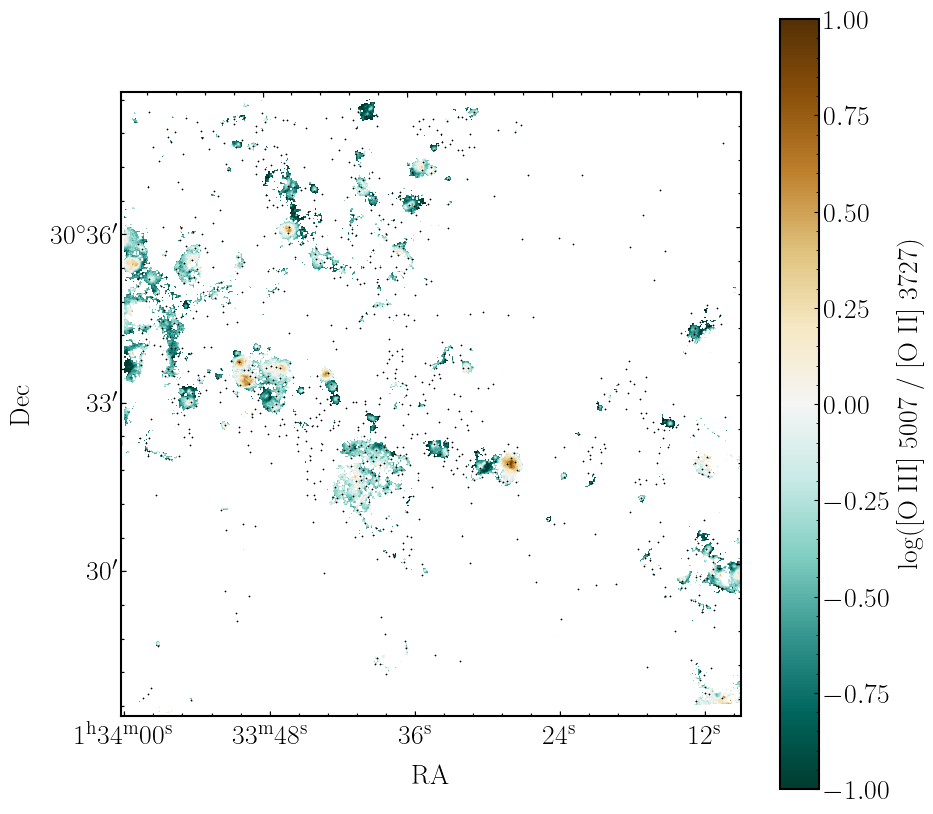

In [11]:
# make a plot of the OIII/OII ratio
field = 'SW'
OIII_flux = fits.getdata("../M33-Maps-Calibrated/M33-SW/M33SW-OIII5007flux.fits")
OII_flux = fits.getdata("../M33-Maps-Calibrated/M33-SW/M33SW-OII3727flux.fits")
OIII_OII_ratio = OIII_flux / OII_flux
wcs_out = WCS(fits.getheader("../M33-Maps-Calibrated/M33-SW/M33SW-OIII5007flux.fits"))
peaks = pd.read_csv("CATALOGS/final_peaks_SW.csv")
#plot OIII/OII ratio map
plt.figure(figsize=(10, 10))
ax = plt.subplot(projection=wcs_out)
im = ax.imshow(np.log10(OIII_OII_ratio), origin="lower", cmap="BrBG_r", vmin=-1, vmax=1)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.scatter(peaks['x'], peaks['y'], transform=ax.get_transform('pixel'), s=1, 
           linewidths=0.5, edgecolors='k', color = 'k', marker = '+', label='HII regions')
plt.colorbar(im, ax=ax, label="log([O III] 5007 / [O II] 3727)")
plt.savefig(f"plots/M33_OIII_OII_ratio_map_{field}.pdf", bbox_inches="tight", dpi=300)

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


def save_ratio_mosaic(
    directory_maps,
    numerator_lines,
    denominator_lines,
    attempt="v1",
    output_basename="M33-LineRatio",
    ratio_label=None,
    cmap="BrBG_r",
    require_all_lines_per_tile=True,
    log10_ratio=True,
    numerator_scale=1e-17,
    denominator_scale=1e-17,
    min_num=None,
    min_den=None,
    finite_clip=None,          # tuple like (vmin, vmax) applied as mask before plotting
    vmin=None,
    vmax=None,

    # ---- emission peak overlay ----
    peaks_directory=None,      # e.g. "CATALOGS"
    peaks_pattern="final_peaks_{field}.csv",
    overlay_peaks=False,
    peak_xcol="x",
    peak_ycol="y",
    peak_style=None,
    peak_label="HII regions",

    # ---- zoom options ----
    zoom_center_pix=None,
    zoom_center_sky=None,
    zoom_size=250,
    zoom_loc="upper right",
    zoom_inset_frac=0.35,
    zoom_box_color="white",
    zoom_box_lw=1.5,
    zoom_mark=True,
    zooms=None,
):
    """
    Build a WCS-aligned mosaic of a line-ratio map and optionally overplot
    emission peaks from per-field CSV catalogs.

    Parameters
    ----------
    directory_maps : str
        Directory containing field subfolders like M33-SW, M33-SE, etc.

    numerator_lines : str or list[str]
        Line(s) to sum in numerator.

    denominator_lines : str or list[str]
        Line(s) to sum in denominator.

    peaks_directory : str or None
        Directory containing per-field peak catalogs.

    peaks_pattern : str
        Filename pattern for peak catalogs, with {field} placeholder.
        Example: "final_peaks_{field}.csv" -> final_peaks_SW.csv

    overlay_peaks : bool
        Whether to overlay emission peaks.

    peak_xcol, peak_ycol : str
        Column names in the peak CSV for pixel coordinates.

    Returns
    -------
    ratio_mosaic, wcs_out
    """

    # -------- normalize inputs --------
    if isinstance(numerator_lines, (str, bytes)):
        numerator_lines = [numerator_lines]
    else:
        numerator_lines = list(numerator_lines)

    if isinstance(denominator_lines, (str, bytes)):
        denominator_lines = [denominator_lines]
    else:
        denominator_lines = list(denominator_lines)

    if ratio_label is None:
        nlab = " + ".join(numerator_lines)
        dlab = " + ".join(denominator_lines)
        ratio_label = f"log10(({nlab}) / ({dlab}))" if log10_ratio else f"({nlab}) / ({dlab})"

    if peak_style is None:
        peak_style = dict(
            s=8,
            linewidths=0.5,
            edgecolors="k",
            color="k",
            marker="+",
        )

    # -------- collect per-tile ratio inputs --------
    ratio_inputs = []

    # collect all peaks in WORLD coordinates so they can be plotted on the mosaic
    peak_ra_all = []
    peak_dec_all = []

    folders = [f for f in os.listdir(directory_maps) if f != ".DS_Store"]
    folders.sort()

    for folder in folders:
        folder_path = os.path.join(directory_maps, folder)
        folder_end = folder_path[-2:]   # e.g. "SW"

        numerator_paths = [
            os.path.join(folder_path, f"M33{folder_end}-{ln}.fits")
            for ln in numerator_lines
        ]
        denominator_paths = [
            os.path.join(folder_path, f"M33{folder_end}-{ln}.fits")
            for ln in denominator_lines
        ]

        needed_paths = numerator_paths + denominator_paths

        if require_all_lines_per_tile and (not all(os.path.exists(p) for p in needed_paths)):
            print(f"Skipping {folder_end} (missing one or more required files)")
            continue

        ref_path = next((p for p in needed_paths if os.path.exists(p)), None)
        if ref_path is None:
            print(f"Skipping {folder_end} (no files found)")
            continue

        # ----- sum numerator maps -----
        num_datas = []
        for p in numerator_paths:
            if not os.path.exists(p):
                if require_all_lines_per_tile:
                    num_datas = []
                    break
                else:
                    continue
            d = fits.getdata(p)
            d = np.where(np.isfinite(d), d / numerator_scale, np.nan)
            num_datas.append(d)

        if len(num_datas) == 0:
            print(f"Skipping {folder_end} (no valid numerator data)")
            continue

        numerator = np.nansum(np.stack(num_datas, axis=0), axis=0)

        # ----- sum denominator maps -----
        den_datas = []
        for p in denominator_paths:
            if not os.path.exists(p):
                if require_all_lines_per_tile:
                    den_datas = []
                    break
                else:
                    continue
            d = fits.getdata(p)
            d = np.where(np.isfinite(d), d / denominator_scale, np.nan)
            den_datas.append(d)

        if len(den_datas) == 0:
            print(f"Skipping {folder_end} (no valid denominator data)")
            continue

        denominator = np.nansum(np.stack(den_datas, axis=0), axis=0)

        # ----- WCS from first available contributing file -----
        w_this = None
        for p in needed_paths:
            if os.path.exists(p):
                w_this = WCS(fits.getheader(p))
                break

        if w_this is None:
            print(f"Skipping {folder_end} (could not build WCS)")
            continue

        # ----- masking / ratio -----
        numerator = np.where(np.isfinite(numerator), numerator, np.nan)
        denominator = np.where(np.isfinite(denominator), denominator, np.nan)

        if min_num is not None:
            numerator = np.where(numerator >= min_num, numerator, np.nan)
        if min_den is not None:
            denominator = np.where(denominator >= min_den, denominator, np.nan)

        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = numerator / denominator

        if log10_ratio:
            ratio = np.where(ratio > 0, ratio, np.nan)
            with np.errstate(divide="ignore", invalid="ignore"):
                ratio = np.log10(ratio)
        else:
            ratio = np.where(np.isfinite(ratio), ratio, np.nan)

        if finite_clip is not None:
            lo, hi = finite_clip
            ratio = np.where((ratio >= lo) & (ratio <= hi), ratio, np.nan)

        ratio_inputs.append((ratio, w_this))

        # ----- optional peaks for this field -----
        if overlay_peaks and (peaks_directory is not None):
            peaks_path = os.path.join(peaks_directory, peaks_pattern.format(field=folder_end))
            if os.path.exists(peaks_path):
                try:
                    peaks = pd.read_csv(peaks_path)

                    if (peak_xcol in peaks.columns) and (peak_ycol in peaks.columns):
                        xpix = peaks[peak_xcol].to_numpy()
                        ypix = peaks[peak_ycol].to_numpy()

                        # convert field pixel coordinates -> sky coordinates
                        sc = w_this.pixel_to_world(xpix, ypix)

                        peak_ra_all.extend(sc.ra.deg)
                        peak_dec_all.extend(sc.dec.deg)
                    else:
                        print(f"Peaks file for {folder_end} missing columns '{peak_xcol}'/'{peak_ycol}'")
                except Exception as e:
                    print(f"Could not read peaks for {folder_end}: {e}")
            else:
                print(f"No peaks catalog found for {folder_end}: {peaks_path}")

    if len(ratio_inputs) == 0:
        raise ValueError("No valid ratio inputs found.")

    # -------- output WCS --------
    wcs_out, shape_out = find_optimal_celestial_wcs(ratio_inputs)

    # -------- mosaic ratio maps --------
    ratio_mosaic, footprint = reproject_and_coadd(
        ratio_inputs,
        wcs_out,
        shape_out=shape_out,
        reproject_function=reproject_interp,
    )

    ratio_mosaic = np.where(footprint > 0, ratio_mosaic, np.nan)

    # -------- plot --------
    fig = plt.figure(figsize=(10, 10))
    ax = plt.subplot(projection=wcs_out)
    ax.coords["ra"].set_ticklabel(size=8)
    ax.coords["dec"].set_ticklabel(size=8)

    im = ax.imshow(
        ratio_mosaic,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xlabel("RA", fontsize=10)
    ax.set_ylabel("Dec", fontsize=10)

    # overplot peaks on the mosaic in WORLD coordinates
    if overlay_peaks and len(peak_ra_all) > 0:
        ax.scatter(
            peak_ra_all,
            peak_dec_all,
            transform=ax.get_transform("world"),
            label=peak_label,
            **peak_style,
        )
        ax.legend(loc="upper right", fontsize=8)

    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(ratio_label, fontsize=10)

    # -------------------------
    # Zoom insets (optional)
    # -------------------------
    if zooms is None:
        zooms = []

    if ((zoom_center_pix is not None) or (zoom_center_sky is not None)) and (len(zooms) == 0):
        zooms = [dict(
            center_pix=zoom_center_pix,
            center_sky=zoom_center_sky,
            size=zoom_size,
            inset_pos=None,
            loc=zoom_loc,
            frac=zoom_inset_frac,
            color=zoom_box_color,
            lw=zoom_box_lw,
            mark=zoom_mark,
        )]

    for zspec in zooms:
        size = zspec.get("size", zoom_size)
        box_color = zspec.get("color", zoom_box_color)
        lw = zspec.get("lw", zoom_box_lw)
        mark = zspec.get("mark", zoom_mark)

        center_pix = zspec.get("center_pix", None)
        center_sky = zspec.get("center_sky", None)

        if (center_pix is None) and (center_sky is None):
            continue

        if center_pix is not None:
            xc, yc = center_pix
        else:
            if isinstance(center_sky, SkyCoord):
                sc = center_sky
            else:
                ra_deg, dec_deg = center_sky
                sc = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame="icrs")
            xc, yc = wcs_out.world_to_pixel(sc)

        half = size / 2.0
        x0 = int(np.floor(xc - half))
        x1 = int(np.ceil(xc + half))
        y0 = int(np.floor(yc - half))
        y1 = int(np.ceil(yc + half))

        H, W = ratio_mosaic.shape
        x0c, x1c = max(0, x0), min(W, x1)
        y0c, y1c = max(0, y0), min(H, y1)

        if (x1c - x0c) < 2 or (y1c - y0c) < 2:
            continue

        rect = plt.Rectangle(
            (x0c, y0c),
            x1c - x0c,
            y1c - y0c,
            fill=False,
            edgecolor=box_color,
            linewidth=lw,
        )
        ax.add_patch(rect)

        inset_pos = zspec.get("inset_pos", None)
        if inset_pos is not None:
            axins = ax.inset_axes(inset_pos, transform=ax.transAxes)
        else:
            loc = zspec.get("loc", zoom_loc)
            frac = zspec.get("frac", zoom_inset_frac)
            axins = inset_axes(
                ax,
                width=f"{100*frac:.0f}%",
                height=f"{100*frac:.0f}%",
                loc=loc,
                borderpad=1.0,
            )

        axins.imshow(
            ratio_mosaic,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        axins.set_xlim(x0c, x1c)
        axins.set_ylim(y0c, y1c)
        axins.set_xticks([])
        axins.set_yticks([])

        for spine in axins.spines.values():
            spine.set_edgecolor(box_color)
            spine.set_linewidth(lw)

        if mark:
            loc1 = zspec.get("mark_loc1", 2)
            loc2 = zspec.get("mark_loc2", 4)
            mark_inset(ax, axins, loc1=loc1, loc2=loc2, fc="none", ec=box_color, lw=lw)

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    os.makedirs("PAPER_PLOTS", exist_ok=True)
    pdf_path = f"PAPER_PLOTS/{output_basename}_{attempt}.pdf"
    plt.savefig(pdf_path, bbox_inches="tight", dpi=600, facecolor="white")
    plt.close(fig)

    print(f"Saved ratio mosaic PDF: {pdf_path}")
    return ratio_mosaic, wcs_out

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


def save_line_mosaic(
    directory_maps,
    lines,
    attempt="v1",
    output_basename="M33-LineMosaic",
    map_label=None,
    cmap="viridis",
    require_all_lines_per_tile=True,
    flux_scale=1e-17,

    # display options
    log10_map=False,
    min_flux=None,
    finite_clip=None,      # tuple like (lo, hi) -> mask outside this range
    vmin=None,
    vmax=None,

    # ---- emission peak overlay ----
    peaks_directory=None,
    peaks_pattern="final_peaks_{field}.csv",
    overlay_peaks=False,
    peak_xcol="x",
    peak_ycol="y",
    peak_style=None,
    peak_label="HII regions",

    # ---- zoom options ----
    zoom_center_pix=None,
    zoom_center_sky=None,
    zoom_size=250,
    zoom_loc="upper right",
    zoom_inset_frac=0.35,
    zoom_box_color="white",
    zoom_box_lw=1.5,
    zoom_mark=True,
    zooms=None,
):
    """
    Build a WCS-aligned mosaic of one emission-line map (or sum of several lines).

    Parameters
    ----------
    directory_maps : str
        Directory containing field subfolders like M33-SW, M33-SE, etc.

    lines : str or list[str]
        One line or several lines to sum.
        Examples:
            "Halpha6563flux"
            ["SII6717flux", "SII6731flux"]

    log10_map : bool
        If True, plot log10(line map). Only positive values are kept.

    min_flux : float or None
        Mask values below this before mosaicing / plotting.

    finite_clip : tuple or None
        Mask values outside (lo, hi).

    Returns
    -------
    line_mosaic, wcs_out
    """

    # -------- normalize inputs --------
    if isinstance(lines, (str, bytes)):
        lines = [lines]
    else:
        lines = list(lines)

    if map_label is None:
        line_label = " + ".join(lines)
        map_label = f"log10({line_label})" if log10_map else line_label

    if peak_style is None:
        peak_style = dict(
            s=8,
            linewidths=0.5,
            edgecolors="k",
            color="k",
            marker="+",
        )

    # -------- collect per-tile inputs --------
    line_inputs = []

    # collect all peaks in world coordinates
    peak_ra_all = []
    peak_dec_all = []

    folders = [f for f in os.listdir(directory_maps) if f != ".DS_Store"]
    folders.sort()

    for folder in folders:
        folder_path = os.path.join(directory_maps, folder)
        folder_end = folder_path[-2:]   # e.g. SW

        line_paths = [
            os.path.join(folder_path, f"M33{folder_end}-{ln}.fits")
            for ln in lines
        ]

        if require_all_lines_per_tile and (not all(os.path.exists(p) for p in line_paths)):
            print(f"Skipping {folder_end} (missing one or more required files)")
            continue

        ref_path = next((p for p in line_paths if os.path.exists(p)), None)
        if ref_path is None:
            print(f"Skipping {folder_end} (no files found)")
            continue

        datas = []
        for p in line_paths:
            if not os.path.exists(p):
                if require_all_lines_per_tile:
                    datas = []
                    break
                else:
                    continue

            d = fits.getdata(p)
            d = np.where(np.isfinite(d), d / flux_scale, np.nan)
            datas.append(d)

        if len(datas) == 0:
            print(f"Skipping {folder_end} (no valid line data)")
            continue

        line_map = np.nansum(np.stack(datas, axis=0), axis=0)

        # WCS from first available contributing file
        w_this = WCS(fits.getheader(ref_path))

        # mask invalid values
        line_map = np.where(np.isfinite(line_map), line_map, np.nan)

        if min_flux is not None:
            line_map = np.where(line_map >= min_flux, line_map, np.nan)

        if log10_map:
            line_map = np.where(line_map > 0, line_map, np.nan)
            with np.errstate(divide="ignore", invalid="ignore"):
                line_map = np.log10(line_map)

        if finite_clip is not None:
            lo, hi = finite_clip
            line_map = np.where((line_map >= lo) & (line_map <= hi), line_map, np.nan)

        line_inputs.append((line_map, w_this))

        # ----- optional peaks for this field -----
        if overlay_peaks and (peaks_directory is not None):
            peaks_path = os.path.join(peaks_directory, peaks_pattern.format(field=folder_end))
            if os.path.exists(peaks_path):
                try:
                    peaks = pd.read_csv(peaks_path)

                    if (peak_xcol in peaks.columns) and (peak_ycol in peaks.columns):
                        xpix = peaks[peak_xcol].to_numpy()
                        ypix = peaks[peak_ycol].to_numpy()

                        sc = w_this.pixel_to_world(xpix, ypix)
                        peak_ra_all.extend(sc.ra.deg)
                        peak_dec_all.extend(sc.dec.deg)
                    else:
                        print(f"Peaks file for {folder_end} missing columns '{peak_xcol}'/'{peak_ycol}'")
                except Exception as e:
                    print(f"Could not read peaks for {folder_end}: {e}")
            else:
                print(f"No peaks catalog found for {folder_end}: {peaks_path}")

    if len(line_inputs) == 0:
        raise ValueError( "No valid line inputs found.")

    # -------- output WCS --------
    wcs_out, shape_out = find_optimal_celestial_wcs(line_inputs)

    # -------- mosaic --------
    line_mosaic, footprint = reproject_and_coadd(
        line_inputs,
        wcs_out,
        shape_out=shape_out,
        reproject_function=reproject_interp,
    )

    line_mosaic = np.where(footprint > 0, line_mosaic, np.nan)

    # -------- plot --------
    fig = plt.figure(figsize=(10, 10))
    ax = plt.subplot(projection=wcs_out)
    ax.coords["ra"].set_ticklabel(size=8)
    ax.coords["dec"].set_ticklabel(size=8)

    im = ax.imshow(
        line_mosaic,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xlabel("RA", fontsize=10)
    ax.set_ylabel("Dec", fontsize=10)

    # overplot peaks
    if overlay_peaks and len(peak_ra_all) > 0:
        ax.scatter(
            peak_ra_all,
            peak_dec_all,
            transform=ax.get_transform("world"),
            label=peak_label,
            **peak_style,
        )
        ax.legend(loc="upper right", fontsize=8)

    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(map_label, fontsize=10)

    # -------------------------
    # Zoom insets (optional)
    # -------------------------
    if zooms is None:
        zooms = []

    if ((zoom_center_pix is not None) or (zoom_center_sky is not None)) and (len(zooms) == 0):
        zooms = [dict(
            center_pix=zoom_center_pix,
            center_sky=zoom_center_sky,
            size=zoom_size,
            inset_pos=None,
            loc=zoom_loc,
            frac=zoom_inset_frac,
            color=zoom_box_color,
            lw=zoom_box_lw,
            mark=zoom_mark,
        )]

    for zspec in zooms:
        size = zspec.get("size", zoom_size)
        box_color = zspec.get("color", zoom_box_color)
        lw = zspec.get("lw", zoom_box_lw)
        mark = zspec.get("mark", zoom_mark)

        center_pix = zspec.get("center_pix", None)
        center_sky = zspec.get("center_sky", None)

        if (center_pix is None) and (center_sky is None):
            continue

        if center_pix is not None:
            xc, yc = center_pix
        else:
            if isinstance(center_sky, SkyCoord):
                sc = center_sky
            else:
                ra_deg, dec_deg = center_sky
                sc = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame="icrs")
            xc, yc = wcs_out.world_to_pixel(sc)

        half = size / 2.0
        x0 = int(np.floor(xc - half))
        x1 = int(np.ceil(xc + half))
        y0 = int(np.floor(yc - half))
        y1 = int(np.ceil(yc + half))

        H, W = line_mosaic.shape
        x0c, x1c = max(0, x0), min(W, x1)
        y0c, y1c = max(0, y0), min(H, y1)

        if (x1c - x0c) < 2 or (y1c - y0c) < 2:
            continue

        rect = plt.Rectangle(
            (x0c, y0c),
            x1c - x0c,
            y1c - y0c,
            fill=False,
            edgecolor=box_color,
            linewidth=lw,
        )
        ax.add_patch(rect)

        inset_pos = zspec.get("inset_pos", None)
        if inset_pos is not None:
            axins = ax.inset_axes(inset_pos, transform=ax.transAxes)
        else:
            loc = zspec.get("loc", zoom_loc)
            frac = zspec.get("frac", zoom_inset_frac)
            axins = inset_axes(
                ax,
                width=f"{100*frac:.0f}%",
                height=f"{100*frac:.0f}%",
                loc=loc,
                borderpad=1.0,
            )

        axins.imshow(
            line_mosaic,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        axins.set_xlim(x0c, x1c)
        axins.set_ylim(y0c, y1c)
        axins.set_xticks([])
        axins.set_yticks([])

        for spine in axins.spines.values():
            spine.set_edgecolor(box_color)
            spine.set_linewidth(lw)

        if mark:
            loc1 = zspec.get("mark_loc1", 2)
            loc2 = zspec.get("mark_loc2", 4)
            mark_inset(ax, axins, loc1=loc1, loc2=loc2, fc="none", ec=box_color, lw=lw)

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    os.makedirs("PAPER_PLOTS", exist_ok=True)
    pdf_path = f"PAPER_PLOTS/{output_basename}_{attempt}.pdf"
    plt.savefig(pdf_path, bbox_inches="tight", dpi=600, facecolor="white")
    plt.close(fig)

    print(f"Saved line mosaic PDF: {pdf_path}")
    return line_mosaic, wcs_out

In [14]:
ratio_map, wcs_out = save_ratio_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    numerator_lines="OIII5007flux",
    denominator_lines="OII3727flux",
    output_basename="M33_OIII_OII_ratio_mosaic",
    ratio_label="log([O III] 5007 / [O II] 3727)",
    cmap="BrBG_r",
    log10_ratio=True,
    vmin=-1,
    vmax=0.5,
    min_den=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_xcol="x",
    peak_ycol="y",
    peak_label="HII regions",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved ratio mosaic PDF: PAPER_PLOTS/M33_OIII_OII_ratio_mosaic_v1.pdf


In [15]:
ratio_map, wcs_out = save_ratio_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    numerator_lines="OIII5007flux",
    denominator_lines=["SII6716flux", "SII6731flux"],
    output_basename="M33_OIII_SII_ratio_mosaic",
    ratio_label="log([O III] 5007 / [S II] 6716, 6731)",
    cmap="PiYG_r",
    log10_ratio=True,
    vmin=-1,
    vmax=1,
    min_den=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_xcol="x",
    peak_ycol="y",
    peak_label="HII regions",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved ratio mosaic PDF: PAPER_PLOTS/M33_OIII_SII_ratio_mosaic_v1.pdf


In [16]:
ratio_map, wcs_out = save_ratio_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    numerator_lines="Haflux",
    denominator_lines="Hbflux",
    output_basename="M33_Ha_Hb_ratio_mosaic",
    ratio_label="log([Ha] / [Hb])",
    cmap="RdBu_r",
    log10_ratio=False,
    vmin=2,
    vmax=4,
    min_den=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_xcol="x",
    peak_ycol="y",
    peak_label="HII regions",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved ratio mosaic PDF: PAPER_PLOTS/M33_Ha_Hb_ratio_mosaic_v1.pdf


In [17]:
ratio_map, wcs_out = save_ratio_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    numerator_lines=["OIII5007flux"],
    denominator_lines="Hbflux",
    output_basename="M33_OIII_Hb_ratio_mosaic",
    ratio_label=r"log([O III] 5007 / H$\beta$)",
    cmap="bwr_r",
    log10_ratio=True,
    vmin=-1,
    vmax=1,
    min_den=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_xcol="x",
    peak_ycol="y",
    peak_label="HII regions",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved ratio mosaic PDF: PAPER_PLOTS/M33_OIII_Hb_ratio_mosaic_v1.pdf


In [18]:
ratio_map, wcs_out = save_ratio_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    numerator_lines=["SII6716flux","SII6731flux"],
    denominator_lines="Haflux",
    output_basename="M33_SII_Ha_ratio_mosaic",
    ratio_label=r"log([S II] 6716, 6731 / H$\alpha$)",
    cmap="PuOr",
    log10_ratio=True,
    vmin=-1.2,
    vmax=0,
    min_den=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_xcol="x",
    peak_ycol="y",
    peak_label="HII regions",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved ratio mosaic PDF: PAPER_PLOTS/M33_SII_Ha_ratio_mosaic_v1.pdf


In [19]:
ratio_map, wcs_out = save_ratio_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    numerator_lines="SII6716flux",
    denominator_lines="SII6731flux",
    output_basename="M33_SII_ratio_mosaic",
    ratio_label=r"log([S II] 6716 / [S II] 6731)",
    cmap="brg",
    log10_ratio=False,
    vmin=1,
    vmax=1.7,
    min_den=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_xcol="x",
    peak_ycol="y",
    peak_label="HII regions",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved ratio mosaic PDF: PAPER_PLOTS/M33_SII_ratio_mosaic_v1.pdf


In [20]:
line_map, wcs_out = save_line_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    lines="OIII5007flux",
    output_basename="M33_OIII5007_mosaic",
    map_label="log([O III] 5007 flux)",
    cmap="rainbow",
    log10_map=True,
    vmin=-1,
    vmax=2,
    min_flux=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved line mosaic PDF: PAPER_PLOTS/M33_OIII5007_mosaic_v1.pdf


In [21]:
line_map, wcs_out = save_line_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    lines="Haflux",
    output_basename="M33_Ha_mosaic",
    map_label=r"log(H$\alpha$ flux)",
    cmap="rainbow",
    log10_map=True,
    vmin=-1,
    vmax=2,
    min_flux=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved line mosaic PDF: PAPER_PLOTS/M33_Ha_mosaic_v1.pdf


In [22]:
line_map, wcs_out = save_line_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    lines="Hbflux",
    output_basename="M33_Hb_mosaic",
    map_label=r"log(H$\beta$ flux)",
    cmap="rainbow",
    log10_map=True,
    vmin=-1,
    vmax=2,
    min_flux=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved line mosaic PDF: PAPER_PLOTS/M33_Hb_mosaic_v1.pdf


In [23]:
line_map, wcs_out = save_line_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    lines="NII6584flux",
    output_basename="M33_NII6584_mosaic",
    map_label=r"log([N II] 6584 flux)",
    cmap="rainbow",
    log10_map=True,
    vmin=-1,
    vmax=2,
    min_flux=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved line mosaic PDF: PAPER_PLOTS/M33_NII6584_mosaic_v1.pdf


In [24]:
line_map, wcs_out = save_line_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    lines="OII3727flux",
    output_basename="M33_OII3727_mosaic",
    map_label=r"log([O II] 3727 flux)",
    cmap="rainbow",
    log10_map=True,
    vmin=-1,
    vmax=2,
    min_flux=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved line mosaic PDF: PAPER_PLOTS/M33_OII3727_mosaic_v1.pdf


In [25]:
line_map, wcs_out = save_line_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    lines=["SII6716flux","SII6731flux"],
    output_basename="M33_SII_mosaic",
    map_label=r"log([S II] 6716,31 flux)",
    cmap="rainbow",
    log10_map=True,
    vmin=-1,
    vmax=2,
    min_flux=1e-3,
    attempt="v1",
    overlay_peaks=True,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_style=dict(
        s=0.1,
        linewidths=0.1,
        color="k",
        marker="o",
    ),
)

Skipping ed (missing one or more required files)


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved line mosaic PDF: PAPER_PLOTS/M33_SII_mosaic_v1.pdf


In [26]:
def save_balmer_av_mosaic(
    directory_maps,
    attempt="v1",
    output_basename="M33-Av-Balmer",
    ha_line="Halpha",
    hb_line="Hbeta",
    cmap="inferno",
    require_all_lines_per_tile=True,
    ha_scale=1e-17,
    hb_scale=1e-17,
    min_ha=None,
    min_hb=None,
    intrinsic_ha_hb=2.86,
    Rv=3.1,
    k_ha=2.535,
    k_hb=3.609,
    av_floor_zero=True,
    finite_clip=None,
    vmin=None,
    vmax=None,
    edge_trim=50,
    axis_label_fontsize=10,

    peaks_directory=None,
    peaks_pattern="final_peaks_{field}.csv",
    overlay_peaks=False,
    peak_xcol="x",
    peak_ycol="y",
    peak_style=None,
    peak_label="HII regions",

    zoom_center_pix=None,
    zoom_center_sky=None,
    zoom_size=250,
    zoom_loc="upper right",
    zoom_inset_frac=0.35,
    zoom_box_color="white",
    zoom_box_lw=1.5,
    zoom_mark=True,
    zooms=None,
):
    """
    Build a WCS-aligned mosaic of Av extinction using the Balmer decrement
    Halpha/Hbeta.

    Assumes case-B intrinsic Halpha/Hbeta = 2.86 by default and a Cardelli-like
    Rv=3.1 extinction curve with k(Halpha)=2.535 and k(Hbeta)=3.609.
    """

    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd

    from astropy.io import fits
    from astropy.wcs import WCS
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    from reproject import reproject_interp
    from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd

    from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

    if peak_style is None:
        peak_style = dict(
            s=8,
            linewidths=0.5,
            edgecolors="k",
            color="k",
            marker="+",
        )

    av_inputs = []
    peak_ra_all = []
    peak_dec_all = []

    folders = [f for f in os.listdir(directory_maps) if f != ".DS_Store"]
    folders.sort()

    for folder in folders:
        folder_path = os.path.join(directory_maps, folder)
        folder_end = folder_path[-2:]

        ha_path = os.path.join(folder_path, f"M33{folder_end}-{ha_line}.fits")
        hb_path = os.path.join(folder_path, f"M33{folder_end}-{hb_line}.fits")

        if require_all_lines_per_tile and not (
            os.path.exists(ha_path) and os.path.exists(hb_path)
        ):
            print(f"Skipping {folder_end} missing Halpha or Hbeta")
            continue

        if not os.path.exists(ha_path) or not os.path.exists(hb_path):
            print(f"Skipping {folder_end} missing Halpha or Hbeta")
            continue

        ha = fits.getdata(ha_path)
        hb = fits.getdata(hb_path)

        ha = np.where(np.isfinite(ha), ha / ha_scale, np.nan)
        hb = np.where(np.isfinite(hb), hb / hb_scale, np.nan)

        if min_ha is not None:
            ha = np.where(ha >= min_ha, ha, np.nan)
        if min_hb is not None:
            hb = np.where(hb >= min_hb, hb, np.nan)

        w_this = WCS(fits.getheader(ha_path))

        with np.errstate(divide="ignore", invalid="ignore"):
            balmer_ratio = ha / hb

            ebv = (2.5 / (k_hb - k_ha)) * np.log10(
                balmer_ratio / intrinsic_ha_hb
            )

            av = Rv * ebv

        av = np.where(np.isfinite(av), av, np.nan)

        if edge_trim is not None and edge_trim > 0:
            trim = int(edge_trim)
            if av.shape[0] > 2 * trim and av.shape[1] > 2 * trim:
                edge_mask = np.zeros(av.shape, dtype=bool)
                edge_mask[trim:-trim, trim:-trim] = True
                av = np.where(edge_mask, av, np.nan)

        # av = np.where(av >= 0, av, np.nan)

        if finite_clip is not None:
            lo, hi = finite_clip
            av = np.where((av >= lo) & (av <= hi), av, np.nan)

        av_inputs.append((av, w_this))

        if overlay_peaks and peaks_directory is not None:
            peaks_path = os.path.join(
                peaks_directory,
                peaks_pattern.format(field=folder_end),
            )

            if os.path.exists(peaks_path):
                peaks = pd.read_csv(peaks_path)

                if peak_xcol in peaks.columns and peak_ycol in peaks.columns:
                    xpix = peaks[peak_xcol].to_numpy()
                    ypix = peaks[peak_ycol].to_numpy()

                    sc = w_this.pixel_to_world(xpix, ypix)

                    peak_ra_all.extend(sc.ra.deg)
                    peak_dec_all.extend(sc.dec.deg)
                else:
                    print(
                        f"Peaks file for {folder_end} missing "
                        f"'{peak_xcol}'/'{peak_ycol}'"
                    )

    if len(av_inputs) == 0:
        raise ValueError("No valid Av inputs found.")

    wcs_out, shape_out = find_optimal_celestial_wcs(av_inputs)

    av_mosaic, footprint = reproject_and_coadd(
        av_inputs,
        wcs_out,
        shape_out=shape_out,
        reproject_function=reproject_interp,
    )

    av_mosaic = np.where(footprint > 0, av_mosaic, np.nan)

    fig = plt.figure(figsize=(10, 10))
    ax = plt.subplot(projection=wcs_out)

    ax.coords["ra"].set_ticklabel(size=8)
    ax.coords["dec"].set_ticklabel(size=8)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="white")   # NaNs → white

    im = ax.imshow(
        av_mosaic,
        origin="lower",
        cmap=cmap_obj,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xlabel("RA", fontsize=axis_label_fontsize)
    ax.set_ylabel("Dec", fontsize=axis_label_fontsize)

    if overlay_peaks and len(peak_ra_all) > 0:
        ax.scatter(
            peak_ra_all,
            peak_dec_all,
            transform=ax.get_transform("world"),
            label=peak_label,
            **peak_style,
        )
        ax.legend(loc="upper right", fontsize=8)

    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(r"$A_V$", fontsize=axis_label_fontsize)
    cbar.ax.tick_params(labelsize=axis_label_fontsize)

    if zooms is None:
        zooms = []

    if ((zoom_center_pix is not None) or (zoom_center_sky is not None)) and len(zooms) == 0:
        zooms = [dict(
            center_pix=zoom_center_pix,
            center_sky=zoom_center_sky,
            size=zoom_size,
            inset_pos=None,
            loc=zoom_loc,
            frac=zoom_inset_frac,
            color=zoom_box_color,
            lw=zoom_box_lw,
            mark=zoom_mark,
        )]

    for zspec in zooms:
        size = zspec.get("size", zoom_size)
        box_color = zspec.get("color", zoom_box_color)
        lw = zspec.get("lw", zoom_box_lw)
        mark = zspec.get("mark", zoom_mark)

        center_pix = zspec.get("center_pix", None)
        center_sky = zspec.get("center_sky", None)

        if center_pix is None and center_sky is None:
            continue

        if center_pix is not None:
            xc, yc = center_pix
        else:
            if isinstance(center_sky, SkyCoord):
                sc = center_sky
            else:
                ra_deg, dec_deg = center_sky
                sc = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame="icrs")
            xc, yc = wcs_out.world_to_pixel(sc)

        half = size / 2.0
        x0 = int(np.floor(xc - half))
        x1 = int(np.ceil(xc + half))
        y0 = int(np.floor(yc - half))
        y1 = int(np.ceil(yc + half))

        H, W = av_mosaic.shape
        x0c, x1c = max(0, x0), min(W, x1)
        y0c, y1c = max(0, y0), min(H, y1)

        if (x1c - x0c) < 2 or (y1c - y0c) < 2:
            continue

        rect = plt.Rectangle(
            (x0c, y0c),
            x1c - x0c,
            y1c - y0c,
            fill=False,
            edgecolor=box_color,
            linewidth=lw,
        )
        ax.add_patch(rect)

        inset_pos = zspec.get("inset_pos", None)
        if inset_pos is not None:
            axins = ax.inset_axes(inset_pos, transform=ax.transAxes)
        else:
            loc = zspec.get("loc", zoom_loc)
            frac = zspec.get("frac", zoom_inset_frac)
            axins = inset_axes(
                ax,
                width=f"{100 * frac:.0f}%",
                height=f"{100 * frac:.0f}%",
                loc=loc,
                borderpad=1.0,
            )

        axins.imshow(
            av_mosaic,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        axins.set_xlim(x0c, x1c)
        axins.set_ylim(y0c, y1c)
        axins.set_xticks([])
        axins.set_yticks([])

        for spine in axins.spines.values():
            spine.set_edgecolor(box_color)
            spine.set_linewidth(lw)

        if mark:
            loc1 = zspec.get("mark_loc1", 2)
            loc2 = zspec.get("mark_loc2", 4)
            mark_inset(
                ax,
                axins,
                loc1=loc1,
                loc2=loc2,
                fc="none",
                ec=box_color,
                lw=lw,
            )

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    os.makedirs("PAPER_PLOTS", exist_ok=True)
    pdf_path = f"PAPER_PLOTS/{output_basename}_{attempt}.pdf"
    plt.savefig(pdf_path, bbox_inches="tight", dpi=600, facecolor="white")
    plt.close(fig)

    print(f"Saved Av mosaic PDF: {pdf_path}")
    return av_mosaic, wcs_out

In [27]:
av_map, wcs_out = save_balmer_av_mosaic(
    directory_maps="../M33-Maps-Calibrated",
    ha_line="Haflux",
    hb_line="Hbflux",
    output_basename="M33_Av_Balmer_mosaic",
    cmap="rainbow",
    vmin=0,
    vmax=3,
    min_ha=1e-3,
    min_hb=1e-3,
    attempt="v1",
    overlay_peaks=False,
    peaks_directory="CATALOGS",
    peaks_pattern="final_peaks_{field}.csv",
    peak_xcol="x",
    peak_ycol="y",
    peak_label="HII regions",
    peak_style=dict(
        s=1,
        linewidths=0.1,
        edgecolor="k",
        facecolors="none",
        marker="o",
    ),
)

Skipping ed missing Halpha or Hbeta


        Use numpy.iterable() instead. [reproject.mosaicking.wcs_helpers]


Saved Av mosaic PDF: PAPER_PLOTS/M33_Av_Balmer_mosaic_v1.pdf
